In [1]:
# Установка и импорт библиотек:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, silhouette_score

from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [2]:
# Скачивание и чтение данных датасета
# Read train and test samples
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train['feats_mod'] = train['features'].apply(lambda x : x.replace('"', '').replace('[', '').replace(']', '').replace("'", ''))
train['feats_mod2'] = train['feats_mod'].apply(lambda x : x.replace(' ', ''))

In [4]:
test['feats_mod'] = test['features'].apply(lambda x : x.replace('"', '').replace('[', '').replace(']', '').replace("'", ''))
test['feats_mod2'] = test['feats_mod'].apply(lambda x : x.replace(' ', ''))

In [5]:
# features_set = set()
features_list = []
for x in train.iterrows():
#     print(x[1]['feats_mod'])
#     features_set.update(set(x[1]['feats_mod'].split(',')))
    features_list+=x[1]['feats_mod'].split(',')

In [6]:
features_list = [x if x != ''  else x for x in features_list ]

In [7]:
features_list = [x if len(x)>0  else x for x in features_list ]

In [8]:
features_list = [x.replace(' ', '') for x in features_list ]

In [9]:
from collections import Counter

In [10]:
cnt = Counter(features_list)

In [11]:
cnt.most_common(21)

[('Elevator', 19059),
 ('HardwoodFloors', 17317),
 ('CatsAllowed', 17229),
 ('DogsAllowed', 16134),
 ('Doorman', 15353),
 ('Dishwasher', 15024),
 ('NoFee', 13369),
 ('LaundryinBuilding', 12090),
 ('FitnessCenter', 9717),
 ('Pre-War', 6762),
 ('LaundryinUnit', 6294),
 ('RoofDeck', 4774),
 ('OutdoorSpace', 3816),
 ('DiningRoom', 3677),
 ('HighSpeedInternet', 3150),
 ('', 2313),
 ('Balcony', 2181),
 ('SwimmingPool', 2012),
 ('LaundryInBuilding', 1941),
 ('NewConstruction', 1859),
 ('Terrace', 1602)]

In [12]:
features_list = [x[0] for x in cnt.most_common(21) if x[0]!='' ]

In [13]:
print(features_list)

['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


In [14]:
for x in features_list:
    train[x] = train['feats_mod2'].str.contains(x).astype(int)
    test[x] = test['feats_mod2'].str.contains(x).astype(int)

In [15]:
basic_features = ['bathrooms',  'bedrooms', 'interest_level']
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list
target = 'price'

In [16]:
xtrain = train[features]
xtest = test[features]

In [17]:
y_train = train[target]
y_test = test[target]

In [18]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])
result_r2 = pd.DataFrame(columns=['model', 'train', 'test'])

In [19]:
silhouette = pd.DataFrame(columns=['model', 'test/all_data'])

## Models

### MinMaxScaler

In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [21]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [22]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [23]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [24]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [25]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(690.6967986092563, 679.4449600453096)

In [26]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(1005.1510196355724, 972.0741648306383)

In [27]:
result_MAE=result_MAE.append({'model' : 'default Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'default Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'default Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\4155737797.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'default Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\4155737797.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'default Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\4155737797.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'default Lasso',


## Clustering KMeans

In [28]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [29]:
cluster_model = KMeans(n_clusters=30, random_state=0)
cluster_model.fit(train[['latitude', 'longitude']])

KMeans(n_clusters=30, random_state=0)

In [30]:
train['cluster_label'] = cluster_model.predict(train[['latitude', 'longitude']])
test['cluster_label'] = cluster_model.predict(test[['latitude', 'longitude']])

In [31]:
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list + ['cluster_label']

xtrain = train[features]
xtest = test[features]

y_train = train[target]
y_test = test[target]

In [32]:
silhouette=silhouette.append({'model' : 'Kmeans',
                              'test/all_data' : silhouette_score(test[['latitude', 'longitude']], test['cluster_label'])}, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\4274149426.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  silhouette=silhouette.append({'model' : 'Kmeans',


In [33]:
cluster_model.inertia_

4.405385466634357

### MinMaxScaler

In [34]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [35]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [36]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [37]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [38]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [39]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(683.2316494584987, 671.230818733592)

In [40]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(991.820499960611, 960.0416798354588)

In [41]:
result_MAE=result_MAE.append({'model' : 'KMeans LatLon Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'KMeans LatLon Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'KMeans LatLon Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\264159257.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'KMeans LatLon Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\264159257.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'KMeans LatLon Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\264159257.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'KMeans LatLon Lasso',


In [42]:
# result_MAE, result_RMSE, result_r2

In [43]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features
feature_importance['imp'] = abs(model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
5,CatsAllowed,0.000000
18,Balcony,14.217749
15,OutdoorSpace,52.986977
12,Pre-War,60.809743
19,SwimmingPool,62.332575
6,DogsAllowed,67.224053
21,NewConstruction,69.136898
9,NoFee,72.451853
14,RoofDeck,106.678402
4,HardwoodFloors,112.352546


C:\Users\jenia\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[(40.65, 40.85)]

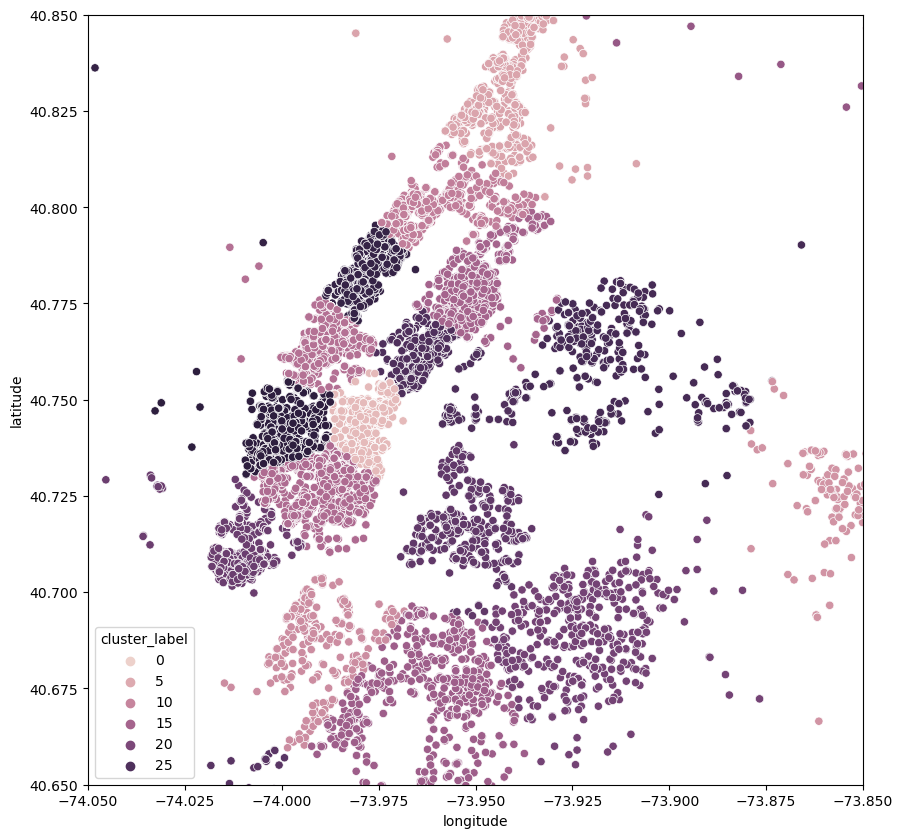

In [44]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(train['longitude'],  train['latitude'], train['cluster_label'])
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

C:\Users\jenia\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[(40.65, 40.85)]

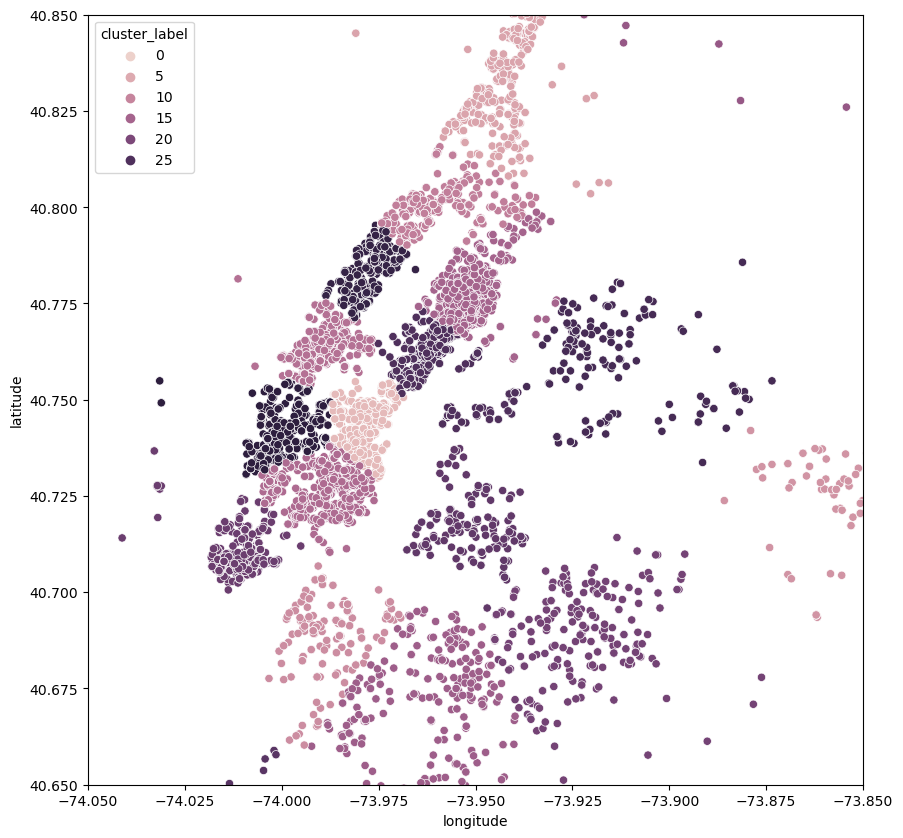

In [45]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(test['longitude'],  test['latitude'], test['cluster_label'])
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

## Clustering AgglomerativeClustering

In [46]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [47]:
cluster_model = AgglomerativeClustering(n_clusters=30)

In [48]:
# cluster_model.fit(train[['latitude', 'longitude']])

train['train'] = 1
test['train'] = 0

data = pd.concat([train, test]).reset_index(drop=True)

In [49]:
data['cluster_label'] = cluster_model.fit_predict(data[['latitude', 'longitude']])
# train['cluster_label'] = cluster_model.fit_predict(train[['latitude', 'longitude']])
# test['cluster_label'] = cluster_model.fit_predict(test[['latitude', 'longitude']])

In [50]:
train = data[data['train']==1].reset_index(drop=True)
test = data[data['train']==0].reset_index(drop=True)

In [51]:
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list + ['cluster_label']

xtrain = train[features]
xtest = test[features]

y_train = train[target]
y_test = test[target]

In [52]:
silhouette=silhouette.append({'model' : 'Agglomerative',
                              'test/all_data' : silhouette_score(data[['latitude', 'longitude']], data['cluster_label'])}, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\2087579327.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  silhouette=silhouette.append({'model' : 'Agglomerative',


### MinMaxScaler

In [53]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [54]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [55]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [56]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [57]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [58]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(675.1586469525047, 661.7645124683569)

In [59]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(990.8261327123585, 955.0366815014868)

In [60]:
result_MAE=result_MAE.append({'model' : 'AgglomerativeClustering LatLon Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'AgglomerativeClustering LatLon Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'AgglomerativeClustering LatLon Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\2738199792.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'AgglomerativeClustering LatLon Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\2738199792.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'AgglomerativeClustering LatLon Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\2738199792.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'AgglomerativeClustering LatLon Lasso',


In [61]:
# result_MAE, result_RMSE, result_r2

In [62]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features
feature_importance['imp'] = abs(model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
5,CatsAllowed,0.000000
18,Balcony,9.343982
12,Pre-War,52.599624
6,DogsAllowed,55.413183
21,NewConstruction,63.064906
15,OutdoorSpace,67.323221
9,NoFee,77.642263
4,HardwoodFloors,94.574295
19,SwimmingPool,94.912227
14,RoofDeck,113.881626


C:\Users\jenia\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[(40.65, 40.85)]

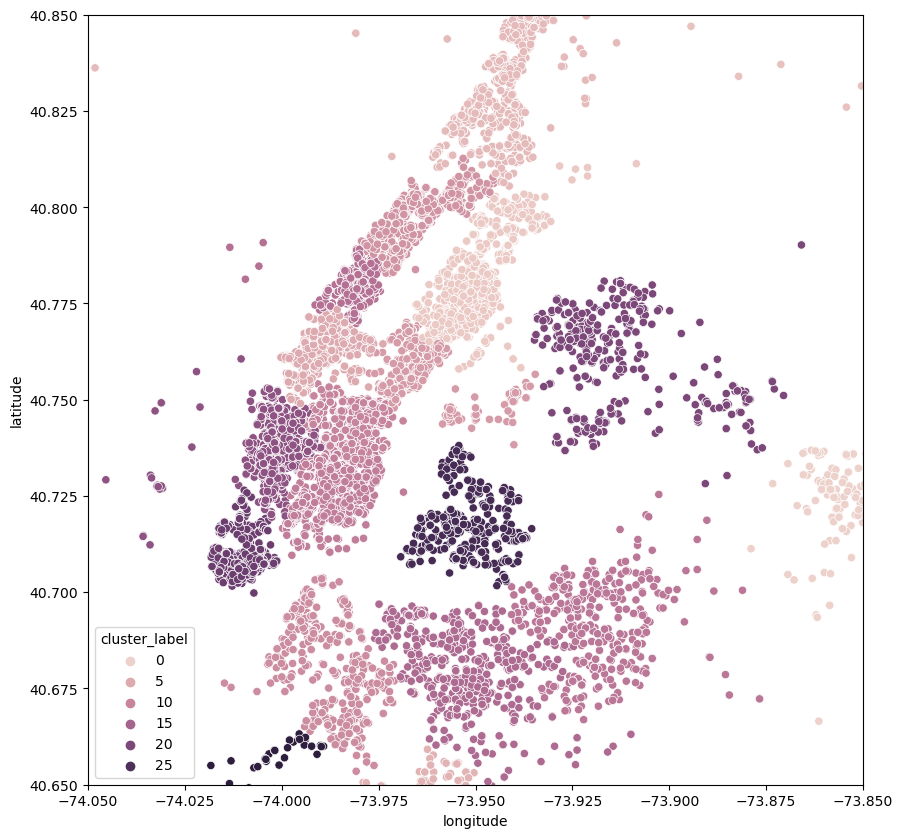

In [63]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(train['longitude'],  train['latitude'], train['cluster_label'])
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

C:\Users\jenia\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[(40.65, 40.85)]

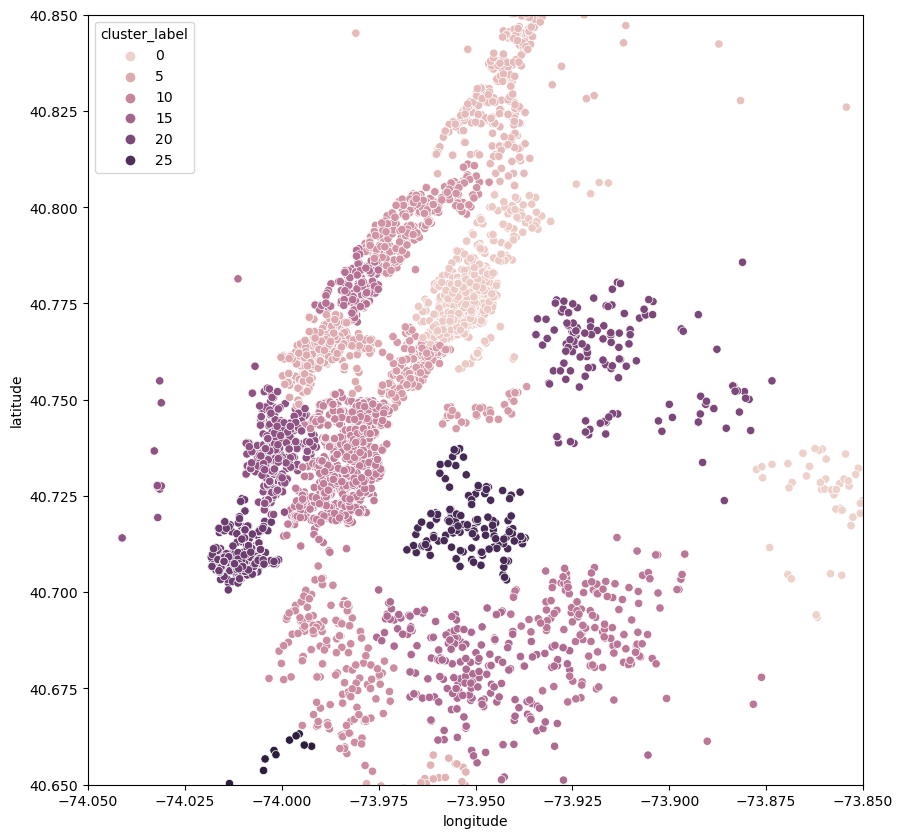

In [64]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(test['longitude'],  test['latitude'], test['cluster_label'])
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

## Clustering DBSCAN

In [65]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [66]:
cluster_model = DBSCAN(min_samples=5, eps=0.001)
# cluster_model.fit(train[['latitude', 'longitude']])

train['train'] = 1
test['train'] = 0

data = pd.concat([train, test]).reset_index(drop=True)

In [67]:
data['cluster_label'] = cluster_model.fit_predict(data[['latitude', 'longitude']])

# train['cluster_label'] = cluster_model.fit_predict(train[['latitude', 'longitude']])
# test['cluster_label'] = cluster_model.fit_predict(test[['latitude', 'longitude']])

In [68]:
train = data[data['train']==1].reset_index(drop=True)
test = data[data['train']==0].reset_index(drop=True)

In [69]:
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list + ['cluster_label']

xtrain = train[features]
xtest = test[features]

y_train = train[target]
y_test = test[target]

In [70]:
silhouette=silhouette.append({'model' : 'DBSCAN',
                              'test/all_data' : silhouette_score(data[['latitude', 'longitude']], data['cluster_label'])}, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3993876656.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  silhouette=silhouette.append({'model' : 'DBSCAN',


### MinMaxScaler

In [71]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [72]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [73]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [74]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [75]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [76]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(680.7358264358159, 668.2765562406203)

In [77]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(993.8243951380069, 962.0399456220832)

In [78]:
result_MAE=result_MAE.append({'model' : 'DBSCAN LatLon Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'DBSCAN LatLon Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'DBSCAN LatLon Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\965049478.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'DBSCAN LatLon Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\965049478.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'DBSCAN LatLon Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\965049478.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'DBSCAN LatLon Lasso',


In [79]:
# result_MAE, result_RMSE, result_r2

In [80]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features
feature_importance['imp'] = abs(model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
18,Balcony,0.000000
5,CatsAllowed,0.000000
21,NewConstruction,2.513493
19,SwimmingPool,32.178338
15,OutdoorSpace,43.032411
12,Pre-War,57.459528
6,DogsAllowed,76.446586
9,NoFee,86.302644
14,RoofDeck,105.510730
8,Dishwasher,120.562048


C:\Users\jenia\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[(40.65, 40.85)]

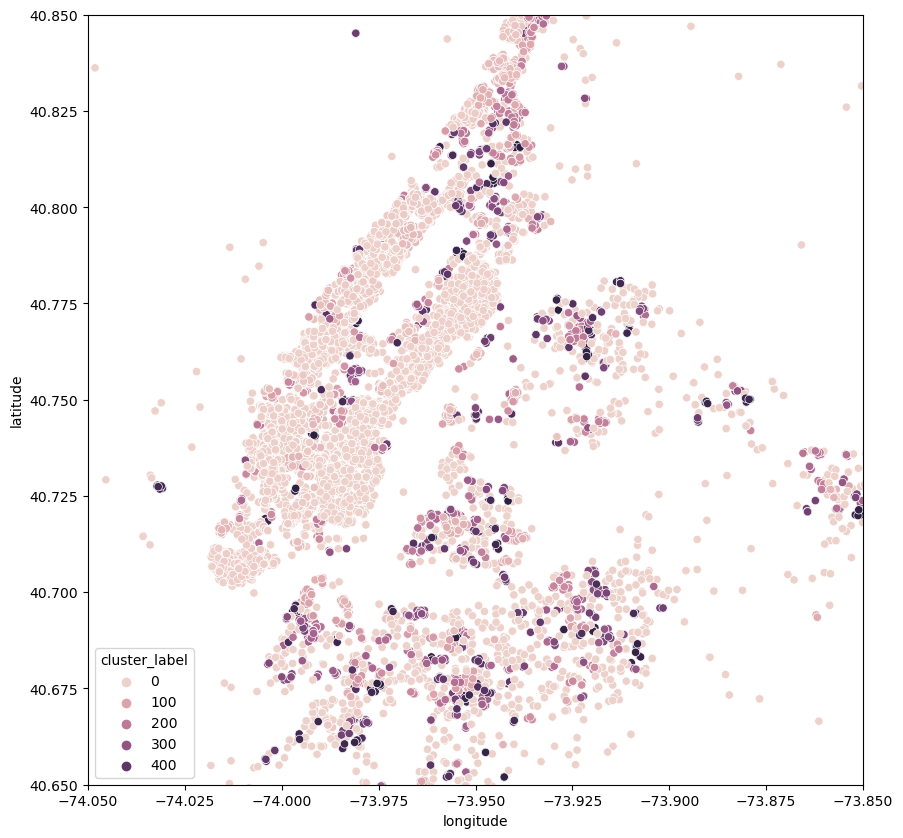

In [81]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(train['longitude'],  train['latitude'], train['cluster_label'])
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

C:\Users\jenia\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[(40.65, 40.85)]

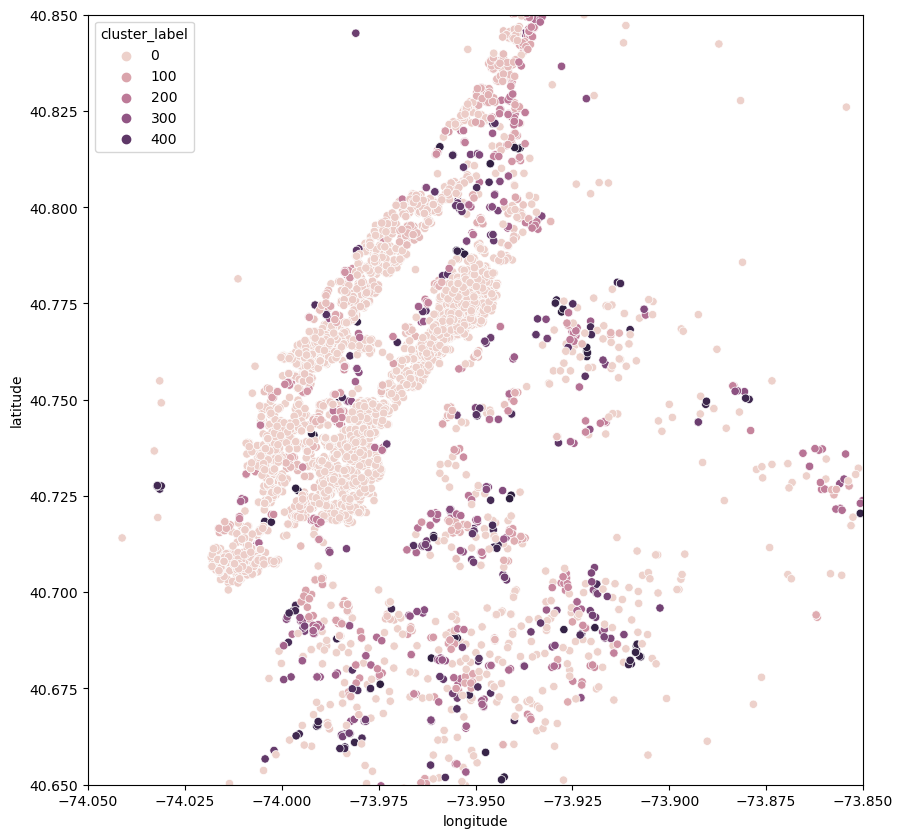

In [82]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(test['longitude'],  test['latitude'], test['cluster_label'])
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

## Clustering GaussianMixture

In [83]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [84]:
cluster_model = GaussianMixture(n_components=30)
cluster_model.fit(train[['latitude', 'longitude']])

GaussianMixture(n_components=30)

In [85]:
train['cluster_label'] = cluster_model.predict(train[['latitude', 'longitude']])
test['cluster_label'] = cluster_model.predict(test[['latitude', 'longitude']])

In [86]:
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list + ['cluster_label']

xtrain = train[features]
xtest = test[features]

y_train = train[target]
y_test = test[target]

In [87]:
silhouette=silhouette.append({'model' : 'GaussianMixture',
                              'test/all_data' : silhouette_score(test[['latitude', 'longitude']], test['cluster_label'])}, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3659031738.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  silhouette=silhouette.append({'model' : 'GaussianMixture',


### MinMaxScaler

In [88]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [89]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [90]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [91]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [92]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [93]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(686.2547325188826, 673.2175928823912)

In [94]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(1001.2737134685422, 966.346196719722)

In [95]:
result_MAE=result_MAE.append({'model' : 'GaussianMixture LatLon Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'GaussianMixture LatLon Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'GaussianMixture LatLon Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\2387428052.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'GaussianMixture LatLon Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\2387428052.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'GaussianMixture LatLon Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\2387428052.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'GaussianMixture LatLon Lasso',


In [96]:
# result_MAE, result_RMSE, result_r2

In [97]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features
feature_importance['imp'] = abs(model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
5,CatsAllowed,0.000000
18,Balcony,0.000000
19,SwimmingPool,36.502693
15,OutdoorSpace,43.745595
12,Pre-War,47.997272
6,DogsAllowed,58.073625
21,NewConstruction,64.068232
9,NoFee,97.619128
4,HardwoodFloors,102.530449
14,RoofDeck,105.715916


C:\Users\jenia\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[(40.65, 40.85)]

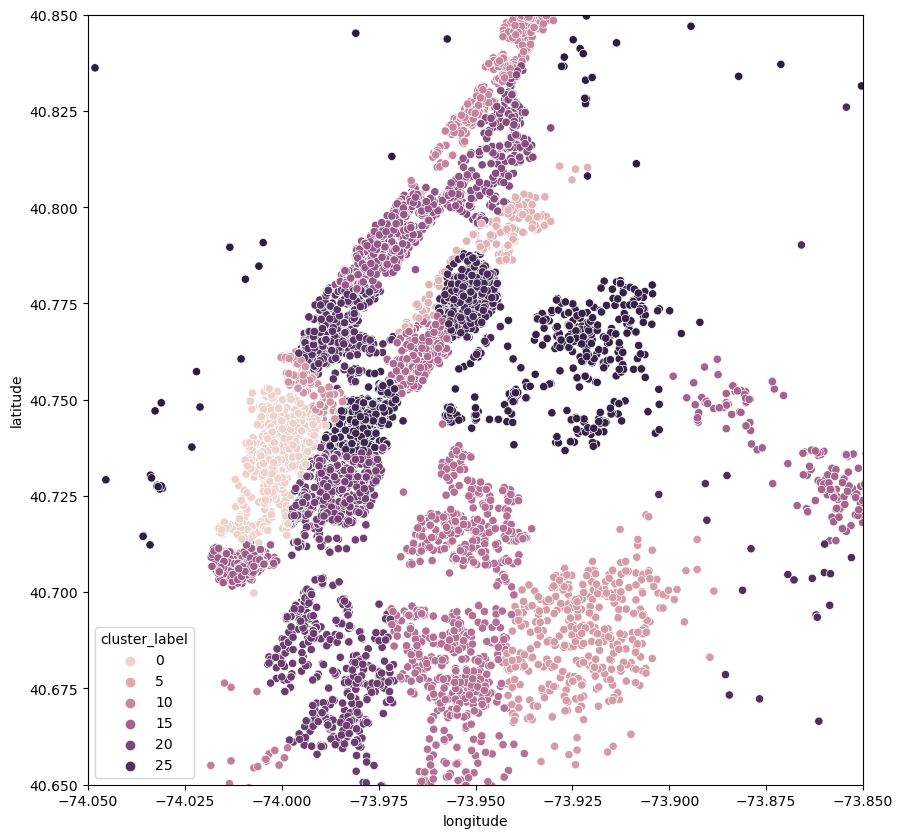

In [98]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(train['longitude'],  train['latitude'], train['cluster_label'])
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

C:\Users\jenia\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y, hue. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[(40.65, 40.85)]

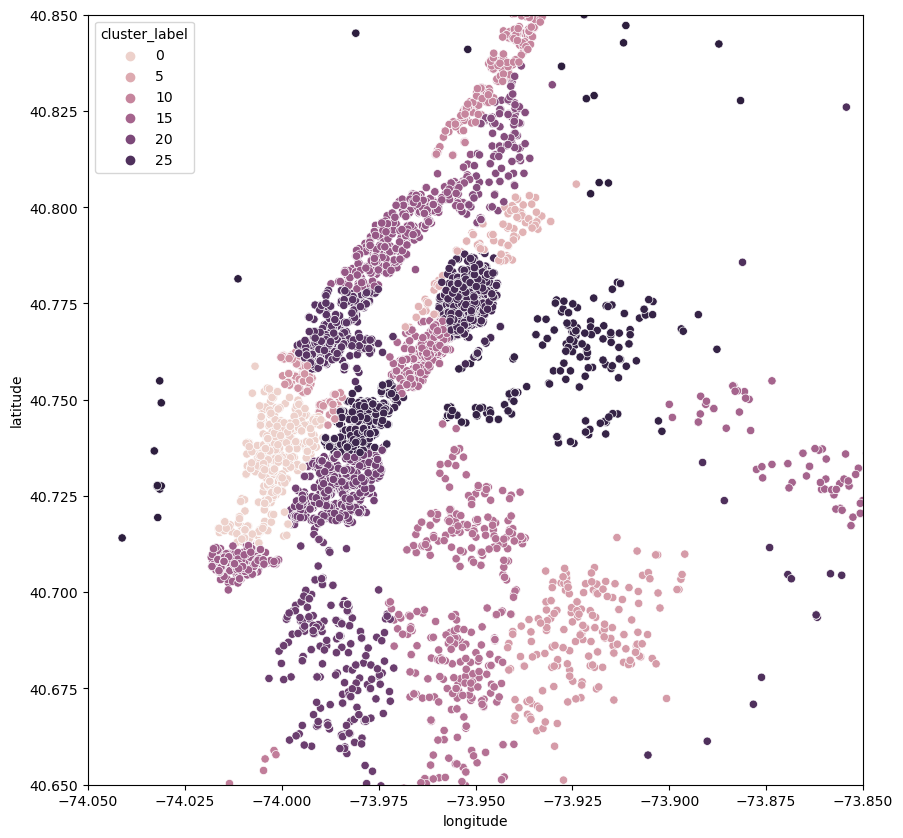

In [99]:
import seaborn as sns
fig = plt.figure(figsize=(10, 10))
g = sns.scatterplot(test['longitude'],  test['latitude'], test['cluster_label'])
g.set(xlim=(-74.05,-73.85))
g.set(ylim=(40.65,40.85))

# New Feature Set

## Clustering KMeans

In [100]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [101]:
cluster_model = KMeans(n_clusters=30, random_state=0)
cluster_model.fit(train[basic_features])

KMeans(n_clusters=30, random_state=0)

In [102]:
train['cluster_label'] = cluster_model.predict(train[basic_features])
test['cluster_label'] = cluster_model.predict(test[basic_features])

In [103]:
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list + ['cluster_label']

xtrain = train[features]
xtest = test[features]

y_train = train[target]
y_test = test[target]

In [104]:
silhouette=silhouette.append({'model' : 'KMeans basic_features',
                              'test/all_data' : silhouette_score(test[['latitude', 'longitude']], test['cluster_label'])}, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3413767904.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  silhouette=silhouette.append({'model' : 'KMeans basic_features',


### MinMaxScaler

In [105]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [106]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [107]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [108]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [109]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [110]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(682.5329733761739, 670.0825917960674)

In [111]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(993.6184324860764, 961.3006519178258)

In [112]:
result_MAE=result_MAE.append({'model' : 'KMeans basic_features Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'KMeans basic_features Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'KMeans basic_features Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\974534303.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'KMeans basic_features Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\974534303.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'KMeans basic_features Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\974534303.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'KMeans basic_features Lasso',


In [113]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features
feature_importance['imp'] = abs(model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
18,Balcony,0.000000
5,CatsAllowed,13.095109
19,SwimmingPool,24.415624
15,OutdoorSpace,35.129012
12,Pre-War,42.880873
21,NewConstruction,47.472779
6,DogsAllowed,89.372502
4,HardwoodFloors,90.966589
14,RoofDeck,97.351270
9,NoFee,97.986766


## Clustering AgglomerativeClustering

In [114]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [115]:
cluster_model = AgglomerativeClustering(n_clusters=30)

In [116]:
# cluster_model.fit(train[['latitude', 'longitude']])

train['train'] = 1
test['train'] = 0

data = pd.concat([train, test]).reset_index(drop=True)

In [117]:
data['cluster_label'] = cluster_model.fit_predict(data[basic_features])
# train['cluster_label'] = cluster_model.fit_predict(train[['latitude', 'longitude']])
# test['cluster_label'] = cluster_model.fit_predict(test[['latitude', 'longitude']])

In [118]:
train = data[data['train']==1].reset_index(drop=True)
test = data[data['train']==0].reset_index(drop=True)

In [119]:
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list + ['cluster_label']

xtrain = train[features]
xtest = test[features]

y_train = train[target]
y_test = test[target]

In [120]:
silhouette=silhouette.append({'model' : 'Agglomerative basic_features',
                              'test/all_data' : silhouette_score(data[basic_features], data['cluster_label'])}, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3080235602.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  silhouette=silhouette.append({'model' : 'Agglomerative basic_features',


### MinMaxScaler

In [121]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [122]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [123]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [124]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [125]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [126]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(690.5651052994341, 679.3619409043298)

In [127]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(1005.0977293478162, 972.123342231886)

In [128]:
result_MAE=result_MAE.append({'model' : 'AgglomerativeClustering basic_features Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'AgglomerativeClustering basic_features Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'AgglomerativeClustering basic_features Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3609460288.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'AgglomerativeClustering basic_features Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3609460288.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'AgglomerativeClustering basic_features Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3609460288.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'AgglomerativeClustering basic_features Lasso',


In [129]:
# result_MAE, result_RMSE, result_r2

In [130]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features
feature_importance['imp'] = abs(model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
18,Balcony,0.000000
5,CatsAllowed,1.766340
23,cluster_label,20.511950
19,SwimmingPool,26.131274
15,OutdoorSpace,42.074900
21,NewConstruction,49.838459
12,Pre-War,50.014844
6,DogsAllowed,69.533335
9,NoFee,93.214960
14,RoofDeck,101.959576


## Clustering DBSCAN

In [131]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [132]:
cluster_model = DBSCAN(min_samples=5, eps=0.001)
# cluster_model.fit(train[['latitude', 'longitude']])

train['train'] = 1
test['train'] = 0

data = pd.concat([train, test]).reset_index(drop=True)

In [133]:
data['cluster_label'] = cluster_model.fit_predict(data[basic_features])

# train['cluster_label'] = cluster_model.fit_predict(train[['latitude', 'longitude']])
# test['cluster_label'] = cluster_model.fit_predict(test[['latitude', 'longitude']])

In [134]:
train = data[data['train']==1].reset_index(drop=True)
test = data[data['train']==0].reset_index(drop=True)

In [135]:
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list + ['cluster_label']

xtrain = train[features]
xtest = test[features]

y_train = train[target]
y_test = test[target]

In [136]:
silhouette=silhouette.append({'model' : 'DBSCAN basic_features',
                              'test/all_data' : silhouette_score(data[basic_features], data['cluster_label'])}, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3833905974.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  silhouette=silhouette.append({'model' : 'DBSCAN basic_features',


### MinMaxScaler

In [137]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [138]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [139]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [140]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [141]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [142]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(689.6788160169435, 678.3486969739881)

In [143]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(1001.9337947387692, 967.7447022930626)

In [144]:
result_MAE=result_MAE.append({'model' : 'DBSCAN basic_features Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'DBSCAN basic_features Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'DBSCAN basic_features Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\1200785702.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'DBSCAN basic_features Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\1200785702.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'DBSCAN basic_features Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\1200785702.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'DBSCAN basic_features Lasso',


In [145]:
# result_MAE, result_RMSE, result_r2

In [146]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features
feature_importance['imp'] = abs(model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
18,Balcony,0.000000
5,CatsAllowed,1.054282
19,SwimmingPool,29.616743
21,NewConstruction,42.701465
15,OutdoorSpace,43.508415
12,Pre-War,47.214902
6,DogsAllowed,74.585252
9,NoFee,95.366099
14,RoofDeck,100.880589
4,HardwoodFloors,106.346094


## Clustering GaussianMixture

In [147]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [148]:
cluster_model = GaussianMixture(n_components=30)
cluster_model.fit(train[basic_features])

GaussianMixture(n_components=30)

In [149]:
train['cluster_label'] = cluster_model.predict(train[basic_features])
test['cluster_label'] = cluster_model.predict(test[basic_features])

In [150]:
features = ['bathrooms',  'bedrooms', 'interest_level'] + features_list + ['cluster_label']

xtrain = train[features]
xtest = test[features]

y_train = train[target]
y_test = test[target]

In [151]:
silhouette=silhouette.append({'model' : 'GaussianMixture basic_features',
                              'test/all_data' : silhouette_score(data[basic_features], data['cluster_label'])} , ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\3020686600.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  silhouette=silhouette.append({'model' : 'GaussianMixture basic_features',


### MinMaxScaler

In [152]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [153]:
# xtrain_norm = pd.DataFrame()
# xtest_norm = pd.DataFrame()

In [154]:
mms = MinMaxScaler()
xtrain_norm = pd.DataFrame(mms.fit_transform(xtrain))
xtest_norm = pd.DataFrame(mms.transform(xtest))

#### Lasso Regression

In [155]:
model = Lasso(random_state=42)
model.fit(xtrain_norm, y_train)

Lasso(random_state=42)

In [156]:
score_train=model.predict(xtrain_norm)
score_test=model.predict(xtest_norm)

In [157]:
mean_absolute_error(y_train, score_train), mean_absolute_error(y_test, score_test)

(685.299016641753, 672.6695626285416)

In [158]:
mean_squared_error(y_train, score_train)**0.5, mean_squared_error(y_test, score_test)**0.5

(997.943751997038, 963.1432110720586)

In [159]:
result_MAE=result_MAE.append({'model' : 'GaussianMixture basic_features Lasso',
                   'train' : mean_absolute_error(y_train, score_train),
                   'test' :  mean_absolute_error(y_test, score_test)
                  }, ignore_index=True)


result_RMSE=result_RMSE.append({'model' : 'GaussianMixture basic_features Lasso',
                   'train' : mean_squared_error(y_train, score_train)**0.5,
                   'test' :  mean_squared_error(y_test, score_test)**0.5
                  }, ignore_index=True)

result_r2=result_r2.append({'model' : 'GaussianMixture basic_features Lasso',
                   'train' : r2_score(y_train, score_train),
                   'test' :  r2_score(y_test, score_test)
                  }, ignore_index=True)

C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\426704889.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_MAE=result_MAE.append({'model' : 'GaussianMixture basic_features Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\426704889.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_RMSE=result_RMSE.append({'model' : 'GaussianMixture basic_features Lasso',
C:\Users\jenia\AppData\Local\Temp\ipykernel_21280\426704889.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_r2=result_r2.append({'model' : 'GaussianMixture basic_features Lasso',


In [160]:
feature_importance = pd.DataFrame()
feature_importance['name'] = features
feature_importance['imp'] = abs(model.coef_)
feature_importance = feature_importance.sort_values('imp')
feature_importance

,name,imp
18,Balcony,0.000000
5,CatsAllowed,0.000000
19,SwimmingPool,31.666242
15,OutdoorSpace,42.096570
12,Pre-War,44.455490
21,NewConstruction,48.504647
6,DogsAllowed,76.885516
9,NoFee,96.924681
4,HardwoodFloors,97.632644
14,RoofDeck,97.895647


In [161]:
result_MAE

,model,train,test
0,default Lasso,690.696799,679.444960
1,KMeans LatLon Lasso,683.231649,671.230819
2,AgglomerativeClustering LatLon Lasso,675.158647,661.764512
3,DBSCAN LatLon Lasso,680.735826,668.276556
4,GaussianMixture LatLon Lasso,686.254733,673.217593
5,KMeans basic_features Lasso,682.532973,670.082592
6,AgglomerativeClustering basic_features Lasso,690.565105,679.361941
7,DBSCAN basic_features Lasso,689.678816,678.348697
8,GaussianMixture basic_features Lasso,685.299017,672.669563


In [162]:
result_RMSE

,model,train,test
0,default Lasso,1005.151020,972.074165
1,KMeans LatLon Lasso,991.820500,960.041680
2,AgglomerativeClustering LatLon Lasso,990.826133,955.036682
3,DBSCAN LatLon Lasso,993.824395,962.039946
4,GaussianMixture LatLon Lasso,1001.273713,966.346197
5,KMeans basic_features Lasso,993.618432,961.300652
6,AgglomerativeClustering basic_features Lasso,1005.097729,972.123342
7,DBSCAN basic_features Lasso,1001.933795,967.744702
8,GaussianMixture basic_features Lasso,997.943752,963.143211


In [163]:
result_r2

,model,train,test
0,default Lasso,0.605611,0.601513
1,KMeans LatLon Lasso,0.616002,0.611317
2,AgglomerativeClustering LatLon Lasso,0.616772,0.615359
3,DBSCAN LatLon Lasso,0.614449,0.609697
4,GaussianMixture LatLon Lasso,0.608648,0.606195
5,KMeans basic_features Lasso,0.614609,0.610297
6,AgglomerativeClustering basic_features Lasso,0.605653,0.601473
7,DBSCAN basic_features Lasso,0.608131,0.605055
8,GaussianMixture basic_features Lasso,0.611246,0.608802


In [164]:
silhouette

,model,test/all_data
0,Kmeans,0.464313
1,Agglomerative,0.479024
2,DBSCAN,-0.172136
3,GaussianMixture,0.389638
4,KMeans basic_features,-0.353663
5,Agglomerative basic_features,0.962029
6,DBSCAN basic_features,0.998269
7,GaussianMixture basic_features,0.998269
